In [1]:
import os, time, json, warnings
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, TrainerCallback
warnings.filterwarnings('ignore', message='Was asked to gather along dimension 0')

DATA_DIR = '/kaggle/input/datasets/pavithra1mj/bert-model-improvements'
OUT_DIR = '/kaggle/working'
MODEL = 'bert-base-uncased'
EPOCHS = 10
SEED = 42

In [2]:
exts = ('.csv', '.tsv', '.txt', '.xlsx', '.xls', '.json', '.jsonl', '.parquet')
root = DATA_DIR if os.path.exists(DATA_DIR) else '/kaggle/input'
cands = [os.path.join(r, f) for r, _, fs in os.walk(root) for f in fs if f.lower().endswith(exts)]
if os.path.isfile(DATA_DIR): cands = [DATA_DIR]
assert cands, os.listdir('/kaggle/input')
for c in cands: print(c, os.path.getsize(c))

def load(path):
    e = os.path.splitext(path)[1].lower()
    if e == '.csv': return pd.read_csv(path)
    if e in ('.tsv', '.txt'): return pd.read_csv(path, sep='\t')
    if e in ('.xlsx', '.xls'): return pd.read_excel(path)
    if e == '.jsonl': return pd.read_json(path, lines=True)
    if e == '.json':
        with open(path) as f: raw = json.load(f)
        if isinstance(raw, dict): raw = next(v for v in raw.values() if isinstance(v, list))
        return pd.DataFrame(raw)
    return pd.read_parquet(path)

df = load(cands[0])
print(cands[0], df.shape)
print(df.dtypes)
print(df.head())

/kaggle/input/datasets/pavithra1mj/bert-model-improvements/labeled_bert_dataset by perplexity.json 857038
/kaggle/input/datasets/pavithra1mj/bert-model-improvements/labeled_bert_dataset by perplexity.json (7953, 2)
text     object
label    object
dtype: object
                                                text   label
0           Compare Donald Trump and Vladimir Putin.  NORMAL
1               They are both political narcissists.  NORMAL
2             Putin is more of an outright dictator.  NORMAL
3                    Donald Trump is not a dictator.  NORMAL
4  Every lawsuit that was against him, he still a...  NORMAL


In [3]:
cols = df.columns.tolist()
TEXT_COL = next((c for c in cols if c.lower() in ('text', 'sentence', 'transcript', 'content')), None)
LABEL_COL = next((c for c in cols if c.lower() in ('label', 'labels', 'class', 'category', 'target')), None)
if TEXT_COL is None:
    TEXT_COL = max([c for c in cols if c != LABEL_COL and df[c].dtype == object], key=lambda c: df[c].astype(str).str.len().mean())
if LABEL_COL is None:
    LABEL_COL = min([c for c in cols if c != TEXT_COL], key=lambda c: df[c].nunique())
print(TEXT_COL, LABEL_COL)

df = df[[TEXT_COL, LABEL_COL]].dropna().drop_duplicates(TEXT_COL).reset_index(drop=True)
le = LabelEncoder()
df['label'] = le.fit_transform(df[LABEL_COL].astype(str))
names = [str(x) for x in le.classes_]
NUM = len(names)
ID2LABEL = {i: n for i, n in enumerate(names)}
LABEL2ID = {n: i for i, n in ID2LABEL.items()}
print(df['label'].map(ID2LABEL).value_counts())

strat = df['label'] if df['label'].value_counts().min() >= 10 else None
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=strat)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'] if strat is not None else None)
print(len(train_df), len(val_df), len(test_df))

text label
label
NORMAL        4916
FILLER        1936
REPETITION     189
BOTH           189
Name: count, dtype: int64
5784 723 723


In [4]:
tok = AutoTokenizer.from_pretrained(MODEL)

class DS(torch.utils.data.Dataset):
    def __init__(self, d):
        self.enc = tok(d[TEXT_COL].astype(str).tolist(), truncation=True, max_length=128)
        self.y = d['label'].astype(int).tolist()
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.y[i]
        return item

train_ds, val_ds, test_ds = DS(train_df), DS(val_df), DS(test_df)
collator = DataCollatorWithPadding(tok)

cw = np.sqrt(compute_class_weight('balanced', classes=np.arange(NUM), y=train_df['label'].values))
print(dict(zip(names, cw.round(3))))
weights = torch.tensor(cw, dtype=torch.float)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

{'BOTH': np.float64(3.095), 'FILLER': np.float64(0.966), 'NORMAL': np.float64(0.606), 'REPETITION': np.float64(3.095)}


In [5]:
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    pw, rw, fw, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted', zero_division=0)
    pm, rm, fm, _ = precision_recall_fscore_support(p.label_ids, preds, average='macro', zero_division=0)
    return {'accuracy': accuracy_score(p.label_ids, preds), 'precision_weighted': pw, 'recall_weighted': rw, 'f1_weighted': fw,
            'precision_macro': pm, 'recall_macro': rm, 'f1_macro': fm}

class WTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(outputs.logits, labels, weight=weights.to(outputs.logits.device))
        return (loss, outputs) if return_outputs else loss

class BestKeeper(TrainerCallback):
    def __init__(self): self.best, self.state, self.epoch = -1, None, None
    def on_evaluate(self, args, state, control, metrics=None, model=None, **kw):
        if metrics and metrics['eval_f1_macro'] > self.best:
            self.best = metrics['eval_f1_macro']
            self.epoch = state.epoch
            self.state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

keeper = BestKeeper()
model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=NUM, id2label=ID2LABEL, label2id=LABEL2ID)

n_gpu = max(1, torch.cuda.device_count())
warmup = int(0.1 * -(-len(train_ds) // (16 * n_gpu)) * EPOCHS)

args = TrainingArguments(
    output_dir=f'{OUT_DIR}/bert_weighted_out',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=warmup,
    eval_strategy='epoch',
    save_strategy='no',
    logging_strategy='epoch',
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to='none'
)

trainer = WTrainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                   data_collator=collator, compute_metrics=compute_metrics, callbacks=[keeper])

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
t0 = time.time()
trainer.train()
train_time = time.time() - t0
trainer.model.load_state_dict(keeper.state)
print(train_time, keeper.epoch, keeper.best)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,Precision Macro,Recall Macro,F1 Macro
1,1.008091,0.422292,0.917012,0.920881,0.917012,0.914821,0.626737,0.692059,0.622447
2,0.325054,0.216237,0.958506,0.963688,0.958506,0.960294,0.820257,0.892272,0.850599
3,0.151122,0.272787,0.964039,0.967889,0.964039,0.965476,0.830602,0.904592,0.863335
4,0.087994,0.301016,0.959889,0.961757,0.959889,0.960619,0.843420,0.890418,0.865346
5,0.036025,0.332182,0.966805,0.969234,0.966805,0.967674,0.844433,0.890597,0.864779
6,0.015388,0.325368,0.962656,0.966133,0.962656,0.963917,0.827489,0.888286,0.853912
7,0.004432,0.355925,0.964039,0.965123,0.964039,0.964511,0.840845,0.865856,0.852756
8,0.001776,0.392347,0.965422,0.967856,0.965422,0.966190,0.843969,0.890089,0.863309
9,0.001574,0.426329,0.966805,0.967806,0.966805,0.967179,0.854577,0.879522,0.865984
10,0.001868,0.432709,0.965422,0.966111,0.965422,0.965710,0.850063,0.866364,0.857737


443.3103744983673 9.0 0.8659844442507914


              precision    recall  f1-score   support

        BOTH       0.72      0.68      0.70        19
      FILLER       0.95      0.97      0.96       194
      NORMAL       0.99      0.99      0.99       491
  REPETITION       0.84      0.84      0.84        19

    accuracy                           0.97       723
   macro avg       0.88      0.87      0.87       723
weighted avg       0.97      0.97      0.97       723



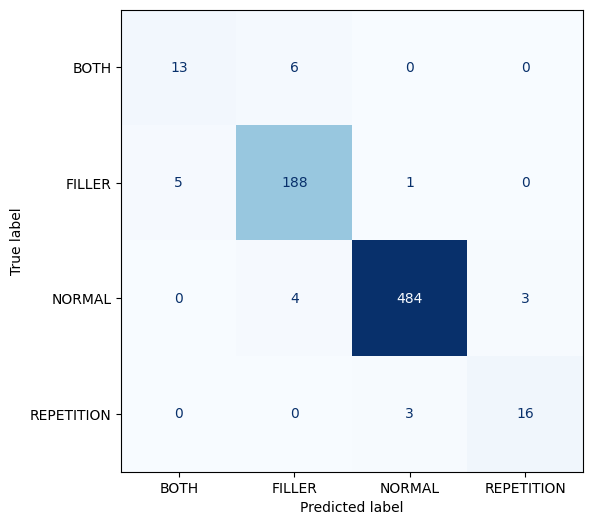

                                                                     0
model                bert-base-uncased (class-weighted, best-val-F1...
epochs                                                              10
best_epoch                                                         9.0
batch_size                                                          16
learning_rate                                                  0.00002
train_samples                                                     5784
val_samples                                                        723
test_samples                                                       723
accuracy                                                      0.969571
precision_weighted                                            0.969432
recall_weighted                                               0.969571
f1_weighted                                                   0.969455
precision_macro                                               0.876406
recall

In [7]:
t1 = time.time()
pred = trainer.predict(test_ds)
eval_time = time.time() - t1

y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)
print(classification_report(y_true, y_pred, labels=range(NUM), target_names=names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=range(NUM))
pd.DataFrame(cm, index=names, columns=names).to_csv(f'{OUT_DIR}/bert_weighted_confusion_matrix.csv')
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(cm, display_labels=names).plot(ax=ax, cmap='Blues', colorbar=False)
plt.savefig(f'{OUT_DIR}/bert_weighted_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

pw, rw, fw, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
pm, rm, fm, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
summary = {
    'model': MODEL + ' (class-weighted, best-val-F1 checkpoint)', 'epochs': EPOCHS, 'best_epoch': keeper.epoch,
    'batch_size': 16, 'learning_rate': 2e-5,
    'train_samples': len(train_ds), 'val_samples': len(val_ds), 'test_samples': len(test_ds),
    'accuracy': accuracy_score(y_true, y_pred),
    'precision_weighted': pw, 'recall_weighted': rw, 'f1_weighted': fw,
    'precision_macro': pm, 'recall_macro': rm, 'f1_macro': fm,
    'train_wall_time_sec': round(train_time, 2), 'eval_wall_time_sec': round(eval_time, 2),
    'total_wall_time_sec': round(train_time + eval_time, 2)
}
pd.DataFrame([summary]).to_csv(f'{OUT_DIR}/bert_weighted_evaluation_metrics.csv', index=False)
p_c, r_c, f_c, s_c = precision_recall_fscore_support(y_true, y_pred, labels=range(NUM), zero_division=0)
pd.DataFrame({'class': names, 'precision': p_c, 'recall': r_c, 'f1': f_c, 'support': s_c}).to_csv(f'{OUT_DIR}/bert_weighted_per_class_metrics.csv', index=False)
pd.DataFrame(trainer.state.log_history).to_csv(f'{OUT_DIR}/bert_weighted_training_log.csv', index=False)
print(pd.read_csv(f'{OUT_DIR}/bert_weighted_evaluation_metrics.csv').T)

In [8]:
trainer.save_model(f'{OUT_DIR}/bert_weighted_finetuned')
tok.save_pretrained(f'{OUT_DIR}/bert_weighted_finetuned')
pd.DataFrame({'label': names, 'id': range(NUM)}).to_csv(f'{OUT_DIR}/bert_weighted_label_map.csv', index=False)

import base64
from IPython.display import HTML, display
for f in ['bert_weighted_evaluation_metrics.csv', 'bert_weighted_per_class_metrics.csv', 'bert_weighted_confusion_matrix.csv', 'bert_weighted_training_log.csv', 'bert_weighted_confusion_matrix.png']:
    b = base64.b64encode(open(f'{OUT_DIR}/{f}', 'rb').read()).decode()
    display(HTML(f'<a download="{f}" href="data:application/octet-stream;base64,{b}">Download {f}</a>'))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]